# MASTER THESIS - model V4 summer

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V15
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-03-05 20:37:19,137 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [3]:
def add_bspline_features(df, n_knots=6, degree=3):
    """Add B-spline basis functions using datetime index."""
    # Extract hour of day from the index (assuming it's datetime)
    hour_of_day = df.index.hour + df.index.minute / 60
    
    # Knots from 6am to 8pm
    knots_interior = np.linspace(6, 20, n_knots)
    knots = np.concatenate([
        [knots_interior[0]] * (degree + 1),
        knots_interior,
        [knots_interior[-1]] * (degree + 1)
    ])
    
    n_basis = len(knots) - degree - 1
    
    for i in range(n_basis):
        coef = np.zeros(n_basis)
        coef[i] = 1.0
        bspline = BSpline(knots, coef, degree)
        df[f'bs_{i}'] = bspline(hour_of_day)
    
    return df, n_basis

In [4]:
input_df = pd.read_csv('./data/data_summer_neighbor.csv', index_col=0, parse_dates=True)

input_df['Ti_meas'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']
input_df['theta_z'] = input_df['HTR9_VES01_AZ01']
input_df['gamma_s'] = input_df['HTR9_VES01_SV01']
input_df['T_neigh_1'] = input_df['R01_02_TRU01']
input_df['T_neigh_2'] = input_df['R01_07_TRU01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti_meas'].iloc[0]
input_df['Tm0'] = input_df['Ti_meas'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning
input_df['P0_Ti'] = 1.0  # Initial state covariance for Ti
input_df['P0_Tm'] = 1.0  # Initial state covariance for Tm
input_df['P0_N'] = 4.0  # Initial state covariance for N


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Ti_meas', 'Tsup', 'theta_z', 'gamma_s', 'Ti0', 'Tm0', 'c0', 'N0', 'T_neigh_1', 'T_neigh_2','P0_Ti', 'P0_Tm', 'P0_N']]
input_y = input_df['Ti_meas']

print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')


Input X shape: (4296, 17), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

# Before training:
X_train, n_bsplines = add_bspline_features(X_train)
X_test, _ = add_bspline_features(X_test)
print(f"Created {n_bsplines} B-spline basis functions")

Train: X shape: (3436, 17), y shape: (3436,)
Test: X shape: (860, 17), y shape: (860,)
Created 10 B-spline basis functions


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.


In [6]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)
orientation = 270                       # West orientation in degrees

A_neigh_1 = 4*H_room                    # Surface of the neighbor wall 1 (m²) - estimated based on Revit
A_neigh_2 = 4*H_room                    # Surface of the neighbor wall 2 (m²) - estimated based on Revit
U_interior_wall = 1.8                   # U-value of interior walls (W/m²K) - single gypsum board + metal stud 

Rneih_1_i = 1/(U_interior_wall*A_neigh_1)
Rneih_2_i = 1/(U_interior_wall*A_neigh_2)


# Define training parameters
train_params_TiTmCn2R2C_summer_V15 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Cm': {'value': 100000, 'vary': True, 'min': 1000, 'max': 1000000},    # Bigger mass\n",
    'Rim': {'value': 0.005, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.15, 'vary': True, 'min': 0.01, 'max': 2.0},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    #'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'gamma_g': {'value': orientation, 'vary': False},                    # glazing angle for IAM calculation
    'n': {'value': 1.526, 'vary': False},                                        # refractive index for IAM calculation
    'K': {'value': 4, 'vary': False},                                   # absorption coefficient for IAM calculation (1/m)
    'L': {'value': 0.003, 'vary': False},                                     # glazing thickness for IAM calculation (m)
    'Rneigh_1': {'value': Rneih_1_i, 'vary': True, 'min': Rneih_1_i*0.1, 'max': Rneih_1_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'Rneigh_2': {'value': Rneih_2_i, 'vary': True, 'min': Rneih_2_i*0.1, 'max': Rneih_2_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'f_sol': {'value': 0.4, 'vary': True, 'min': 0, 'max': 1},         # Solar gains distribution factor (fraction of solar gains directly affecting indoor air node)
    
    # 10 B-spline coefficients
    'phi_a': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_b': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_c': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_d': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_e': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_f': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_g': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},  
    'phi_h': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_i': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_j': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    
    'sigma_Ti_meas': {'value': 0.05, 'vary': False},   # typical PT100/NTC accuracy ±0.05K
    'sigma_Ti': {'value': 0.02, 'vary': True, 'min': 1e-4, 'max': 1.0},   # Process noise std for Ti --- IGNORE ---
    'sigma_Tm': {'value': 0.01, 'vary': True, 'min': 1e-4, 'max': 1.0},  # Process noise std for Tm --- IGNORE ---

    'sigma_N': {'value': 0.5, 'vary': True, 'min': 0.01, 'max': 5.0},    'sigma_Ti_meas': {'value': 0.3, 'vary': False},  # Measurement noise std for Ti (from sensor spec)
    'sigma_c': {'value': 50.0, 'vary': False},  # Measurement noise std for CO2 (from sensor spec)
    'P0_Ti': {'value': 1.0, 'vary': False},  # Initial state covariance for Ti
    'P0_Tm': {'value': 1.0, 'vary': False},  # Initial state covariance for Tm
    'P0_N': {'value': 4.0, 'vary': False},  # Initial state covariance for N (assuming we are quite uncertain about initial occupancy)  
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [7]:
from lmfit import Parameters, minimize as lmfit_minimize

method = 'nelder'

# ── Convert dict → lmfit Parameters ──────────────────────────────────────────
def build_lmfit_params(params_dict):
    p = Parameters()
    for name, spec in params_dict.items():
        if isinstance(spec, dict):
            p.add(name, **{k: v for k, v in spec.items()
                           if k in ('value', 'vary', 'min', 'max', 'expr')})
        else:
            p.add(name, value=float(spec))
    return p

lmfit_params = build_lmfit_params(train_params_TiTmCn2R2C_summer_V15)

# ── Model instance ────────────────────────────────────────────────────────────
model = TiTmCn2R2C_summer_V15(train_params_TiTmCn2R2C_summer_V15, rec_duration)

# ── Log-likelihood objective (mathematically required for KF model) ───────────
def loglik_objective(params):
    result = model.model(params, X_train)
    z = result.var['z_Ti'][1:]
    S = result.var['S_Ti'][1:]
    return 0.5 * np.sum(z**2 / S + np.log(S))

# ── Fit ───────────────────────────────────────────────────────────────────────
print("Training model...")
fit_result    = lmfit_minimize(loglik_objective, lmfit_params, method=method)
model.result  = fit_result
fitted_params = fit_result.params

# ── Train prediction ──────────────────────────────────────────────────────────
train_results = model.model(fitted_params, X_train)

# ── Test initial conditions + prediction ─────────────────────────────────────
test_params = fitted_params.copy()
test_params['Ti0'].set(value=float(y_test.iloc[0]))
test_params['Tm0'].set(value=float(train_results.var['Tm'][-1]))
test_params['c0'].set(value=float(train_results.var['c'][-1]))
test_params['N0'].set(value=float(train_results.var['N'][-1]))

test_results = model.model(test_params, X_test)
print("Fitting complete!")

# ── Display parameters ────────────────────────────────────────────────────────
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

# ── Parameter comparison table ────────────────────────────────────────────────
try:
    init_params = {'Ci': {'value': Ci_i}, 'Cm': {'value': Cm_i},
                   'Rim': {'value': Rim_i}, 'Rout': {'value': Rout_i}}
except NameError:
    init_params = {'Ci': {'value': None}, 'Cm': {'value': None},
                   'Rim': {'value': None}, 'Rout': {'value': None}}

real_init_params = {}
for key in ['Ci', 'Cm', 'Rim', 'Rout']:
    try:
        real_init_params[key] = train_params_TiTmCn2R2C_summer_V15[key]['value']
    except Exception:
        real_init_params[key] = None

if hasattr(model, "result") and hasattr(model.result, "params"):
    est_params = model.result.params
    print("Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value")
    print("--------------------------------------------------------------------------")
    for key in ['Ci', 'Cm', 'Rim', 'Rout']:
        init_val      = init_params[key]['value']
        real_init_val = real_init_params[key]
        est_val       = est_params[key].value if key in est_params else None
        if init_val is not None and real_init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif real_init_val is not None and est_val is not None:
            print(f"{key:10} | {'N/A':>18} | {real_init_val:23.4f} | {est_val:15.4f}")
        else:
            print(f"{key:10} | {'N/A':>18} | {'N/A':>23} | {'N/A':>15}")

# ── RMSE for reporting (separate from the fitting criterion) ──────────────────
from docs.tutorials.util.error import rmse
test_rmse  = rmse(test_results.var['Ti'], y_test.values)
train_rmse = rmse(train_results.var['Ti'], y_train.values)
print(f"Train RMSE (Ti): {train_rmse:.4f} °C")
print(f"Test  RMSE (Ti): {test_rmse:.4f} °C")


Training model...
Fitting complete!


name,value,initial value,min,max,vary
Ti0,25.3672727,25.36727273,-inf,inf,False
Tm0,25.3672727,25.36727273,-inf,inf,False
c0,433.680000,433.68,-inf,inf,False
N0,0.00000000,0.0,-inf,inf,False
Ci,1000.19534,5000.0,1000.00000,50000.0000,True
Cm,4167.99849,100000.0,1000.00000,1000000.00,True
Rim,0.00153473,0.005,1.0000e-03,0.01000000,True
Rout,0.08885421,0.15,0.01000000,2.00000000,True
q_pers,75.0000000,75.0,-inf,inf,False
q_equip_var,80.0000000,80.0,-inf,inf,False


Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value
--------------------------------------------------------------------------
Ci         |                N/A |               5000.0000 |       1000.1953
Cm         |                N/A |             100000.0000 |       4167.9985
Rim        |                N/A |                  0.0050 |          0.0015
Rout       |                N/A |                  0.1500 |          0.0889
Train RMSE (Ti): 0.1049 °C
Test  RMSE (Ti): 0.0775 °C


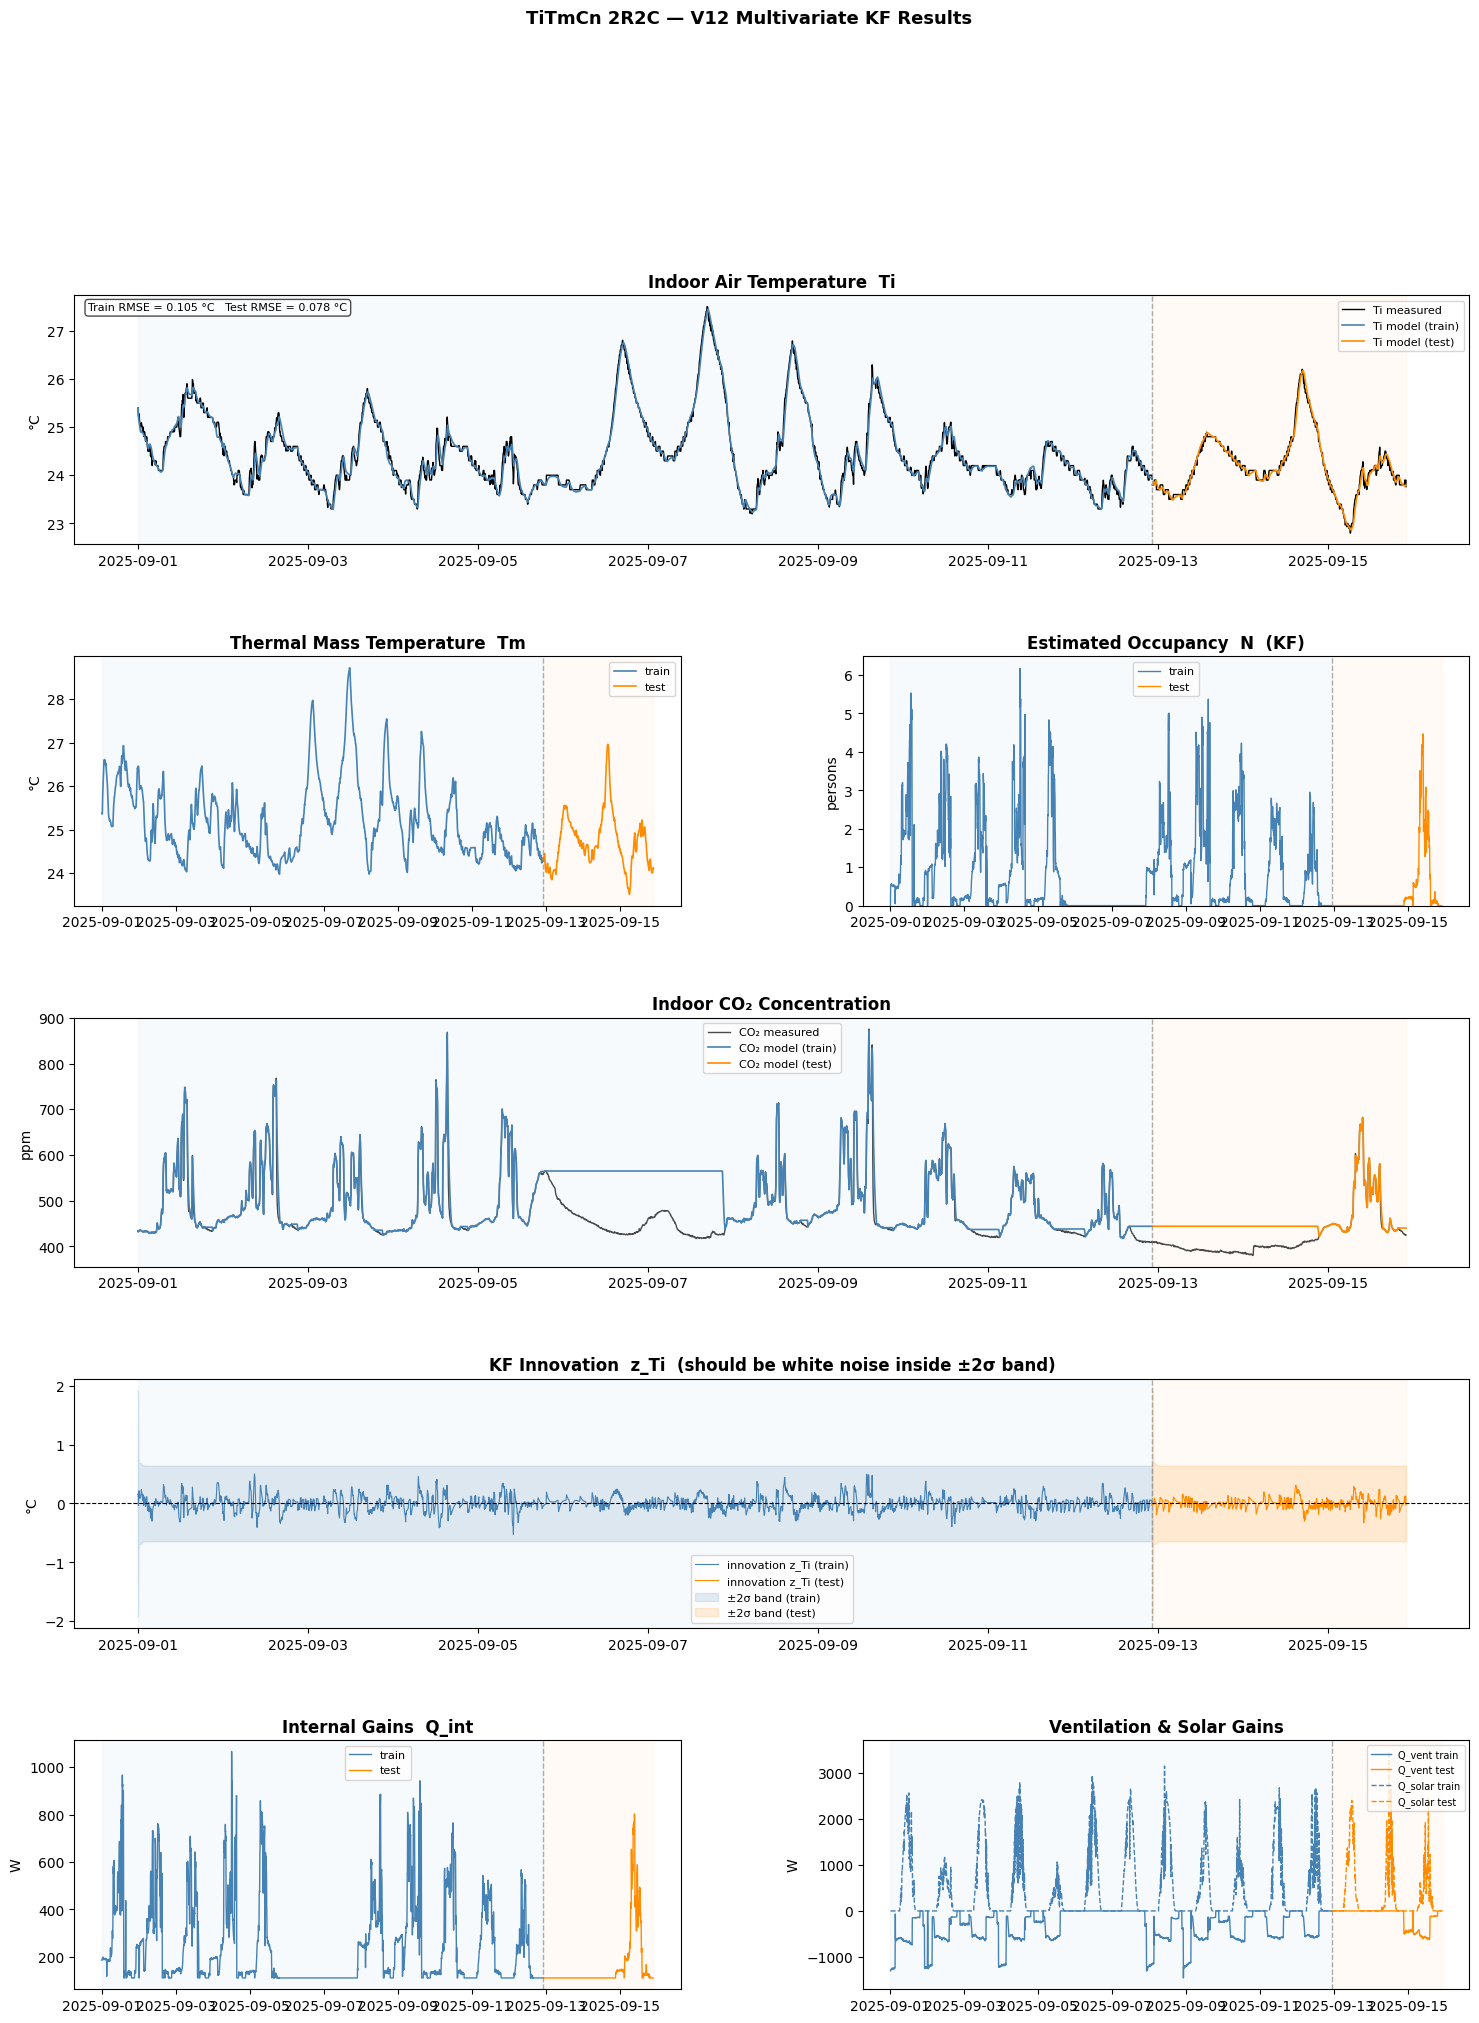

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = train_results.var['Ti']
Tm_train   = train_results.var['Tm']
N_train    = train_results.var['N']
c_train    = train_results.var['c']
z_train    = train_results.var['z_Ti']
S_train    = train_results.var['S_Ti']
Qint_train = train_results.var['Q_int']
Qven_train = train_results.var['Q_vent']
Qsol_train = train_results.var['Q_solar']

Ti_test    = test_results.var['Ti']
Tm_test    = test_results.var['Tm']
N_test     = test_results.var['N']
c_test     = test_results.var['c']
z_test     = test_results.var['z_Ti']
S_test     = test_results.var['S_Ti']
Qint_test  = test_results.var['Q_int']
Qven_test  = test_results.var['Q_vent']
Qsol_test  = test_results.var['Q_solar']

c_meas_train = np.asarray(X_train['c'],      dtype=float)
c_meas_test  = np.asarray(X_test['c'],       dtype=float)

sigma_2_train = 2.0 * np.sqrt(np.abs(S_train))
sigma_2_test  = 2.0 * np.sqrt(np.abs(S_test))

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])   # full width — main result
ax_tm   = fig.add_subplot(gs[1, 0])
ax_n    = fig.add_subplot(gs[1, 1])
ax_co2  = fig.add_subplot(gs[2, :])   # full width
ax_inn  = fig.add_subplot(gs[3, :])   # full width — KF diagnostic
ax_qint = fig.add_subplot(gs[4, 0])
ax_qven = fig.add_subplot(gs[4, 1])

# ── Helper: shade train / test ────────────────────────────────────────────────
def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Indoor air temperature Ti ──────────────────────────────────────────────
ax_ti.plot(train_index, y_train,   color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train,  color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,    color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,   color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Thermal mass temperature Tm ────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Thermal Mass Temperature  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 concentration ──────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. KF innovations z_Ti with ±2σ band (whiteness diagnostic) ──────────────
ax_inn.plot(train_index, z_train,         color='steelblue',  lw=0.8, label='innovation z_Ti (train)')
ax_inn.plot(test_index,  z_test,          color='darkorange', lw=0.8, label='innovation z_Ti (test)')
ax_inn.fill_between(train_index,  sigma_2_train, -sigma_2_train,
                    color='steelblue',  alpha=0.15, label='±2σ band (train)')
ax_inn.fill_between(test_index,   sigma_2_test,  -sigma_2_test,
                    color='darkorange', alpha=0.15, label='±2σ band (test)')
ax_inn.axhline(0, color='black', lw=0.8, ls='--')
shade_split(ax_inn)
ax_inn.set_title('KF Innovation  z_Ti  (should be white noise inside ±2σ band)', fontweight='bold')
ax_inn.set_ylabel('°C')
ax_inn.legend(fontsize=8)

# ── 6. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 7. Ventilation + solar gains ──────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

fig.suptitle('TiTmCn 2R2C — V12 Multivariate KF Results', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('V12_results.png', dpi=150, bbox_inches='tight')
plt.show()


# Indicators


═══════════════════════════════════════════════════════
  EXTENDED MODEL VALIDATION REPORT — V12 KF
═══════════════════════════════════════════════════════

  GOODNESS OF FIT
  Metric                  Train       Test
  ----------------------------------------
  RMSE                   0.1049 °C       0.0775 °C
  MAE                    0.0783 °C       0.0585 °C
  NRMSE                  0.0244       0.0228
  R2                     0.9816       0.9840
  Bias                  -0.0027 °C      -0.0014 °C

  LIKELIHOOD-BASED CRITERIA (train)
  Log-Likelihood : 3661.80
  AIC            : -7281.60  (lower = better)
  BIC            : -7152.61  (lower = better)
  Free params    : 21

  KF INNOVATION DIAGNOSTICS
  Test                                  Train         Test
  --------------------------------------------------------
  ε mean (ideal=0)                     0.0097       0.0049
  ε std  (ideal=1)                     0.3742       0.2766
  Shapiro-Wilk  p-val                  0.0000       

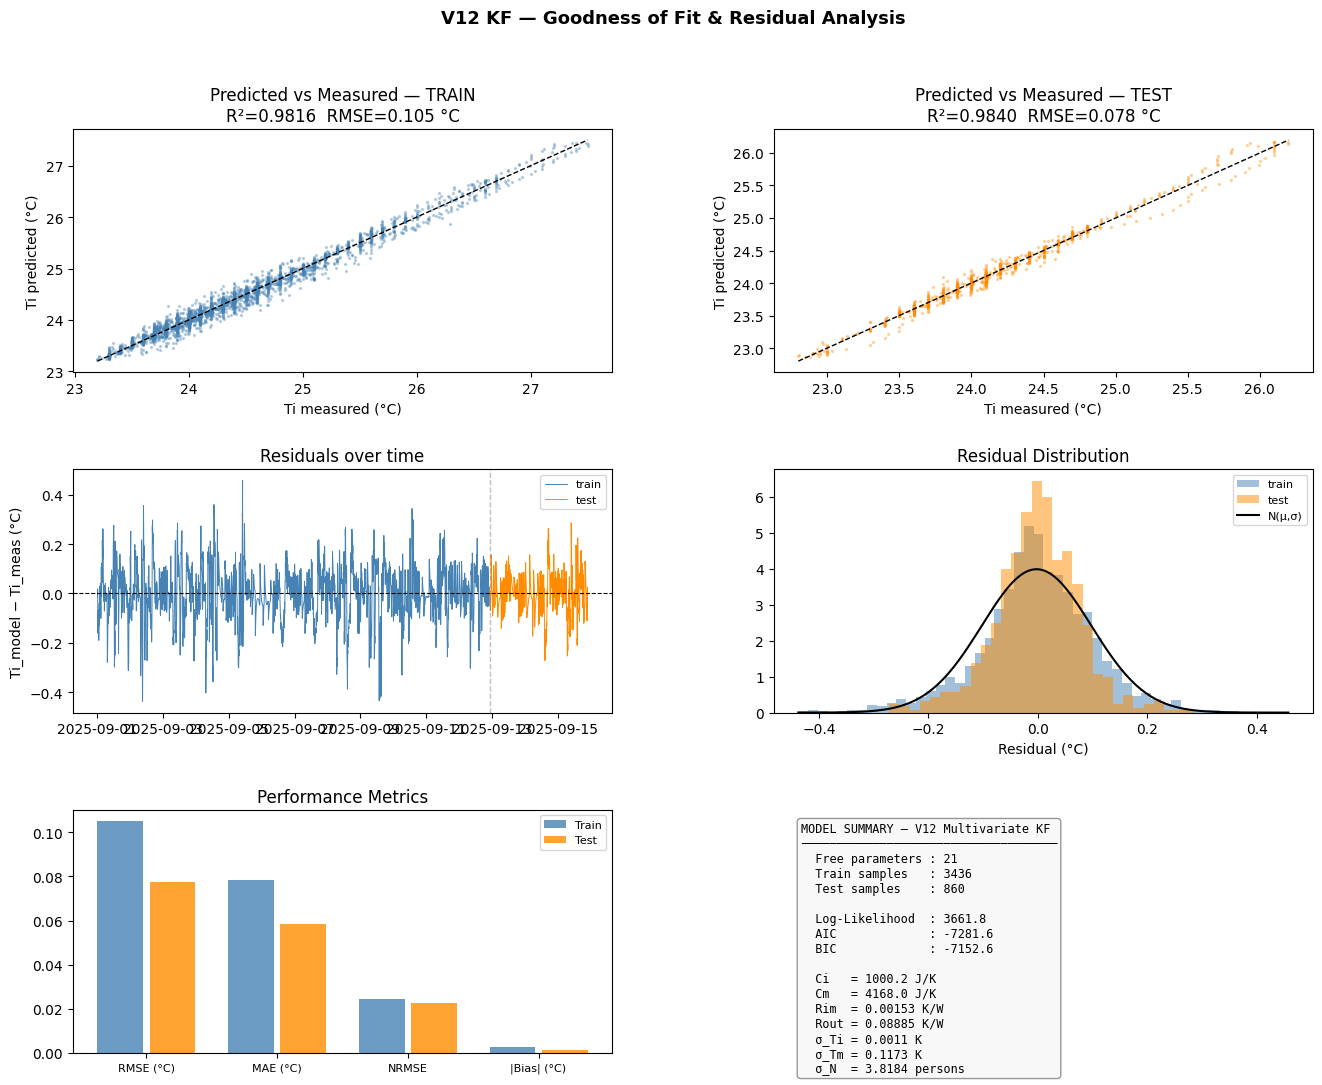

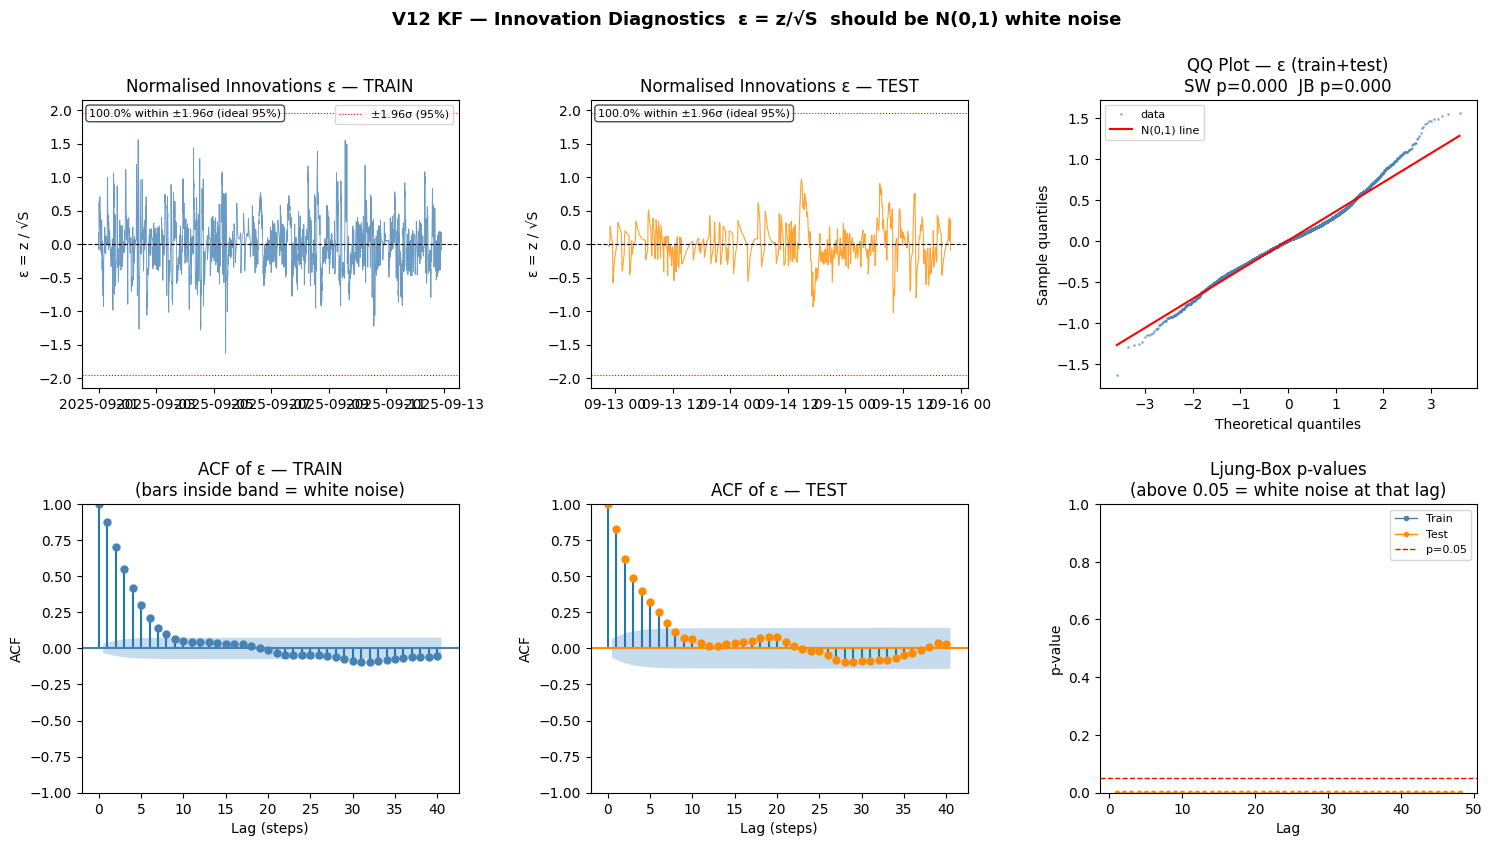

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import jarque_bera, shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# ═══════════════════════════════════════════════════════════════════════════════
# COMPUTE ALL INDICATORS
# ═══════════════════════════════════════════════════════════════════════════════

# ── Raw residuals (Ti model - Ti measured) ────────────────────────────────────
res_train = train_results.var['Ti'] - y_train.values
res_test  = test_results.var['Ti']  - y_test.values

# ── Normalised innovations ε = z / sqrt(S)  →  should be N(0,1) ──────────────
z_tr = train_results.var['z_Ti'][1:]
S_tr = train_results.var['S_Ti'][1:]
z_te = test_results.var['z_Ti'][1:]
S_te = test_results.var['S_Ti'][1:]
eps_train = z_tr / np.sqrt(np.abs(S_tr))   # normalised innovations (train)
eps_test  = z_te / np.sqrt(np.abs(S_te))   # normalised innovations (test)

# ── Number of free parameters (vary=True) ────────────────────────────────────
n_params = sum(1 for p in fitted_params.values() if p.vary)
n_train  = len(y_train)
n_test   = len(y_test)

# ── Log-likelihood (train, computed from innovations) ────────────────────────
loglik_train = -0.5 * np.sum(z_tr**2 / S_tr + np.log(S_tr))
loglik_test  = -0.5 * np.sum(z_te**2 / S_te + np.log(S_te))

# ── AIC / BIC (use train log-likelihood and n_train) ─────────────────────────
AIC  = -2 * loglik_train + 2 * n_params
BIC  = -2 * loglik_train + n_params * np.log(n_train)

# ── Goodness-of-fit metrics ───────────────────────────────────────────────────
def mae(pred, obs):    return np.mean(np.abs(pred - obs))
def nrmse(pred, obs):  return rmse(pred, obs) / (obs.max() - obs.min())
def r2(pred, obs):     return 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)
def bias(pred, obs):   return np.mean(pred - obs)

metrics = {
    'Train': dict(
        RMSE   = rmse(train_results.var['Ti'], y_train.values),
        MAE    = mae(train_results.var['Ti'],  y_train.values),
        NRMSE  = nrmse(train_results.var['Ti'], y_train.values),
        R2     = r2(train_results.var['Ti'],   y_train.values),
        Bias   = bias(train_results.var['Ti'], y_train.values),
    ),
    'Test': dict(
        RMSE   = rmse(test_results.var['Ti'],  y_test.values),
        MAE    = mae(test_results.var['Ti'],   y_test.values),
        NRMSE  = nrmse(test_results.var['Ti'], y_test.values),
        R2     = r2(test_results.var['Ti'],    y_test.values),
        Bias   = bias(test_results.var['Ti'],  y_test.values),
    ),
}

# ── Normality tests on normalised innovations ─────────────────────────────────
sw_stat_tr, sw_p_tr = shapiro(eps_train[:5000])    # Shapiro-Wilk (max 5000 pts)
jb_stat_tr, jb_p_tr = jarque_bera(eps_train)
sw_stat_te, sw_p_te = shapiro(eps_test)
jb_stat_te, jb_p_te = jarque_bera(eps_test)

# ── Ljung-Box whiteness test on normalised innovations ────────────────────────
lb_train = acorr_ljungbox(eps_train, lags=[1, 12, 24], return_df=True)
lb_test  = acorr_ljungbox(eps_test,  lags=[1, 12, 24], return_df=True)

# ── Print full report ─────────────────────────────────────────────────────────
sep = "═" * 55
print(f"\n{sep}")
print("  EXTENDED MODEL VALIDATION REPORT — V12 KF")
print(sep)
print(f"\n  {'GOODNESS OF FIT':}")
print(f"  {'Metric':<18} {'Train':>10} {'Test':>10}")
print(f"  {'-'*40}")
for k in ['RMSE', 'MAE', 'NRMSE', 'R2', 'Bias']:
    unit = ' °C' if k in ('RMSE','MAE','Bias') else ''
    print(f"  {k:<18} {metrics['Train'][k]:>10.4f}{unit}   {metrics['Test'][k]:>10.4f}{unit}")

print(f"\n  {'LIKELIHOOD-BASED CRITERIA (train)'}")
print(f"  Log-Likelihood : {loglik_train:.2f}")
print(f"  AIC            : {AIC:.2f}  (lower = better)")
print(f"  BIC            : {BIC:.2f}  (lower = better)")
print(f"  Free params    : {n_params}")

print(f"\n  {'KF INNOVATION DIAGNOSTICS':}")
print(f"  {'Test':<30} {'Train':>12} {'Test':>12}")
print(f"  {'-'*56}")
print(f"  {'ε mean (ideal=0)':<30} {eps_train.mean():>12.4f} {eps_test.mean():>12.4f}")
print(f"  {'ε std  (ideal=1)':<30} {eps_train.std():>12.4f} {eps_test.std():>12.4f}")
print(f"  {'Shapiro-Wilk  p-val':<30} {sw_p_tr:>12.4f} {sw_p_te:>12.4f}")
print(f"  {'Jarque-Bera   p-val':<30} {jb_p_tr:>12.4f} {jb_p_te:>12.4f}")
for lag, row_tr, row_te in zip(
    [1,12,24],
    lb_train['lb_pvalue'].values,
    lb_test['lb_pvalue'].values
):
    print(f"  {'Ljung-Box lag='+str(lag)+' p-val':<30} {row_tr:>12.4f} {row_te:>12.4f}")
print(f"\n  NOTE: p > 0.05 → cannot reject H0 (residuals white / Gaussian)")
print(sep + "\n")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Goodness of fit + residuals
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(3, 2, figsize=(16, 12))
fig1.suptitle('V12 KF — Goodness of Fit & Residual Analysis', fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.3)

train_index = X_train.index
test_index  = X_test.index

# ── (1,1) Predicted vs measured (train) ──────────────────────────────────────
ax = axes[0, 0]
mn, mx = y_train.min(), y_train.max()
ax.scatter(y_train, train_results.var['Ti'], s=2, alpha=0.3, color='steelblue')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Ti measured (°C)')
ax.set_ylabel('Ti predicted (°C)')
ax.set_title(f'Predicted vs Measured — TRAIN\nR²={metrics["Train"]["R2"]:.4f}  RMSE={metrics["Train"]["RMSE"]:.3f} °C')

# ── (1,2) Predicted vs measured (test) ───────────────────────────────────────
ax = axes[0, 1]
mn, mx = y_test.min(), y_test.max()
ax.scatter(y_test, test_results.var['Ti'], s=2, alpha=0.3, color='darkorange')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Ti measured (°C)')
ax.set_ylabel('Ti predicted (°C)')
ax.set_title(f'Predicted vs Measured — TEST\nR²={metrics["Test"]["R2"]:.4f}  RMSE={metrics["Test"]["RMSE"]:.3f} °C')

# ── (2,1) Residuals over time ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(train_index, res_train, color='steelblue',  lw=0.7, label='train')
ax.plot(test_index,  res_test,  color='darkorange', lw=0.7, label='test')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Ti_model − Ti_meas (°C)')
ax.set_title('Residuals over time')
ax.legend(fontsize=8)

# ── (2,2) Residual histogram (train + test) ───────────────────────────────────
ax = axes[1, 1]
all_res = np.concatenate([res_train, res_test])
ax.hist(res_train, bins=50, density=True, alpha=0.5, color='steelblue', label='train')
ax.hist(res_test,  bins=30, density=True, alpha=0.5, color='darkorange', label='test')
xr = np.linspace(all_res.min(), all_res.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, all_res.mean(), all_res.std()),
        'k-', lw=1.5, label='N(μ,σ)')
ax.set_xlabel('Residual (°C)')
ax.set_title('Residual Distribution')
ax.legend(fontsize=8)

# ── (3,1) Metrics bar chart ───────────────────────────────────────────────────
ax = axes[2, 0]
bar_labels = ['RMSE (°C)', 'MAE (°C)', 'NRMSE', '|Bias| (°C)']
train_vals = [metrics['Train']['RMSE'], metrics['Train']['MAE'],
              metrics['Train']['NRMSE'], abs(metrics['Train']['Bias'])]
test_vals  = [metrics['Test']['RMSE'],  metrics['Test']['MAE'],
              metrics['Test']['NRMSE'],  abs(metrics['Test']['Bias'])]
x = np.arange(len(bar_labels))
ax.bar(x - 0.2, train_vals, 0.35, label='Train', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, test_vals,  0.35, label='Test',  color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_title('Performance Metrics')
ax.legend(fontsize=8)

# ── (3,2) Model info text box ─────────────────────────────────────────────────
ax = axes[2, 1]
ax.axis('off')
info = (
    f"MODEL SUMMARY — V12 Multivariate KF\n"
    f"{'─'*36}\n"
    f"  Free parameters : {n_params}\n"
    f"  Train samples   : {n_train}\n"
    f"  Test samples    : {n_test}\n\n"
    f"  Log-Likelihood  : {loglik_train:.1f}\n"
    f"  AIC             : {AIC:.1f}\n"
    f"  BIC             : {BIC:.1f}\n\n"
    f"  Ci   = {fitted_params['Ci'].value:.1f} J/K\n"
    f"  Cm   = {fitted_params['Cm'].value:.1f} J/K\n"
    f"  Rim  = {fitted_params['Rim'].value:.5f} K/W\n"
    f"  Rout = {fitted_params['Rout'].value:.5f} K/W\n"
    f"  σ_Ti = {fitted_params['sigma_Ti'].value:.4f} K\n"
    f"  σ_Tm = {fitted_params['sigma_Tm'].value:.4f} K\n"
    f"  σ_N  = {fitted_params['sigma_N'].value:.4f} persons"
)
ax.text(0.05, 0.95, info, transform=ax.transAxes, va='top',
        fontsize=8.5, family='monospace',
        bbox=dict(boxstyle='round', fc='#f7f7f7', ec='grey', alpha=0.8))

plt.savefig('V12_goodness_of_fit.png', dpi=150, bbox_inches='tight')
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — KF Innovation diagnostics (the key SDE-specific plots)
# ═══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))
fig2.suptitle('V12 KF — Innovation Diagnostics  ε = z/√S  should be N(0,1) white noise',
              fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# ── (1,1) Normalised innovations over time (train) ───────────────────────────
ax = axes2[0, 0]
ax.plot(train_index[1:], eps_train, lw=0.6, color='steelblue', alpha=0.8)
ax.axhline( 0, color='black', lw=0.8, ls='--')
ax.axhline( 1.96, color='red', lw=0.8, ls=':', label='±1.96σ (95%)')
ax.axhline(-1.96, color='red', lw=0.8, ls=':')
ax.set_title('Normalised Innovations ε — TRAIN')
ax.set_ylabel('ε = z / √S')
ax.legend(fontsize=8)
pct_in = np.mean(np.abs(eps_train) < 1.96) * 100
ax.text(0.02, 0.97, f'{pct_in:.1f}% within ±1.96σ (ideal 95%)',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── (1,2) Normalised innovations over time (test) ────────────────────────────
ax = axes2[0, 1]
ax.plot(test_index[1:], eps_test, lw=0.8, color='darkorange', alpha=0.8)
ax.axhline( 0, color='black', lw=0.8, ls='--')
ax.axhline( 1.96, color='red', lw=0.8, ls=':')
ax.axhline(-1.96, color='red', lw=0.8, ls=':')
ax.set_title('Normalised Innovations ε — TEST')
ax.set_ylabel('ε = z / √S')
pct_in = np.mean(np.abs(eps_test) < 1.96) * 100
ax.text(0.02, 0.97, f'{pct_in:.1f}% within ±1.96σ (ideal 95%)',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── (1,3) QQ plot of normalised innovations ───────────────────────────────────
ax = axes2[0, 2]
all_eps = np.concatenate([eps_train, eps_test])
(osm, osr), (slope, intercept, r) = stats.probplot(all_eps, dist='norm')
ax.plot(osm, osr,     '.', ms=2, color='steelblue', alpha=0.5, label='data')
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=1.5, label='N(0,1) line')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title(f'QQ Plot — ε (train+test)\nSW p={sw_p_tr:.3f}  JB p={jb_p_tr:.3f}')
ax.legend(fontsize=8)

# ── (2,1) ACF of normalised innovations (train) ───────────────────────────────
ax = axes2[1, 0]
plot_acf(eps_train, lags=40, ax=ax, color='steelblue', alpha=0.05)
ax.set_title('ACF of ε — TRAIN\n(bars inside band = white noise)')
ax.set_xlabel('Lag (steps)')
ax.set_ylabel('ACF')

# ── (2,2) ACF of normalised innovations (test) ────────────────────────────────
ax = axes2[1, 1]
plot_acf(eps_test, lags=40, ax=ax, color='darkorange', alpha=0.05)
ax.set_title('ACF of ε — TEST')
ax.set_xlabel('Lag (steps)')
ax.set_ylabel('ACF')

# ── (2,3) Ljung-Box p-values across lags ─────────────────────────────────────
ax = axes2[1, 2]
max_lag = min(48, len(eps_train)//5)
lb_tr_full = acorr_ljungbox(eps_train, lags=range(1, max_lag+1), return_df=True)
lb_te_full = acorr_ljungbox(eps_test,  lags=range(1, max_lag+1), return_df=True)
ax.plot(lb_tr_full.index, lb_tr_full['lb_pvalue'], 'o-', ms=3,
        color='steelblue',  lw=1, label='Train')
ax.plot(lb_te_full.index, lb_te_full['lb_pvalue'], 'o-', ms=3,
        color='darkorange', lw=1, label='Test')
ax.axhline(0.05, color='red', lw=1, ls='--', label='p=0.05')
ax.set_xlabel('Lag')
ax.set_ylabel('p-value')
ax.set_title('Ljung-Box p-values\n(above 0.05 = white noise at that lag)')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

plt.savefig('V12_innovation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
